In [564]:
import torch
from torch import nn
import matplotlib.pyplot as plt

 # Linear regression

In [565]:
# Y = a + bX

# parameters
weight = 0.7 # b
bias = 0.3 # a

# data
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(1)
y = weight * X + bias

In [566]:
X[:5], y[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

In [567]:
len(X), len(y)

(50, 50)

In [568]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [569]:
def plot_preds(train_data,train_labels,test_data,test_labels,preds=None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data,train_labels,c="b",s=4,label="Training data")
  plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")
  if preds is not None:
    plt.scatter(test_data,preds,c="r",s=4,label="Predictions")
  plt.legend()

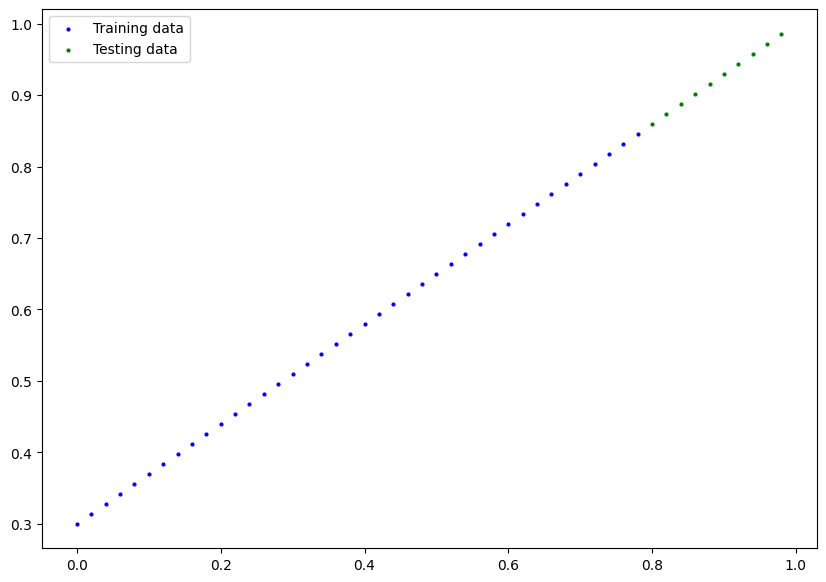

In [570]:
plot_preds(X_train,y_train,X_test,y_test)

In [573]:
class LinearRegressionModel(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
    self.bias = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)

  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.weight * x + self.bias

# starts with random values
# adjusts the random values looking at the training data to minimize the error
# uses a loss function and an optimizer to do that
# requires_grad=True tells pytorch to update the parameter using gradient decent

# forward pass → prediction
# loss function → compares prediction vs. actual label, outputs a single number (the error/loss)
# backpropagation → computes the gradient of that loss with respect to every weight (i.e., how much changing each weight would change the loss)
# optimizer → takes those gradients and decides how exactly to update the weights (gradient descent is the most basic optimizer)

# gradient decent → weight = weight - learning_rate * gradient

In [574]:
torch.manual_seed(42)
model = LinearRegressionModel()

In [575]:
list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [576]:
model.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [577]:
with torch.inference_mode():
  y_pred = model(X_test)
y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

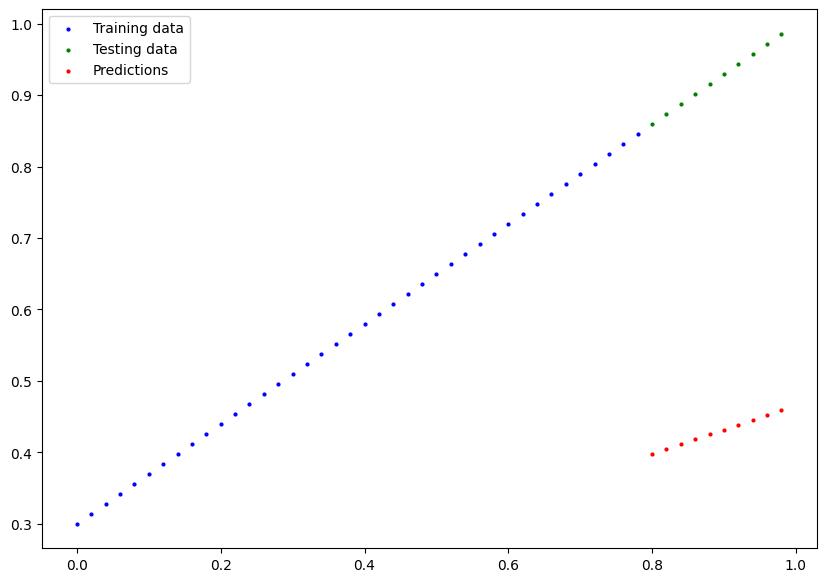

In [578]:
plot_preds(X_train,y_train,X_test,y_test,y_pred)

In [ ]:
# loss_fn = torch.mean(torch.abs(y_pred-y_test))
loss_fn = nn.L1Loss()

In [ ]:
optimizer = torch.optim.SGD(params=model.parameters(),lr=0.01)

In [ ]:
# forward propagation
# calculate loss
# optimizer zero grad
# backward propagation
# step the optimizer

In [ ]:
model.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
epochs = 200
torch.manual_seed(42)

epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
  model.train() # sets the model in training mode
  y_pred = model(X_train) # forward propagation
  loss = loss_fn(y_pred,y_train) # calculate loss
  optimizer.zero_grad() # optimizer zero grad
  loss.backward() # backward propagation
  optimizer.step() # step the optimizer

  model.eval() # sets the model in evaluation mode
  with torch.inference_mode():
    test_pred = model(X_test)
    test_loss = loss_fn(test_pred,y_test)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss.detach())
    test_loss_values.append(test_loss)

    print(f"Epoch {epoch} Loss: {loss} Test loss: {test_loss}")
    print(model.state_dict())
    print()

print(f"Epoch {epoch} Loss: {loss} Test loss: {test_loss}")
print(model.state_dict())

Epoch 0 Loss: 0.31288138031959534 Test loss: 0.48106518387794495
OrderedDict({'weight': tensor([0.3406]), 'bias': tensor([0.1388])})

Epoch 10 Loss: 0.1976713240146637 Test loss: 0.3463551998138428
OrderedDict({'weight': tensor([0.3796]), 'bias': tensor([0.2388])})

Epoch 20 Loss: 0.08908725529909134 Test loss: 0.21729660034179688
OrderedDict({'weight': tensor([0.4184]), 'bias': tensor([0.3333])})

Epoch 30 Loss: 0.053148526698350906 Test loss: 0.14464017748832703
OrderedDict({'weight': tensor([0.4512]), 'bias': tensor([0.3768])})

Epoch 40 Loss: 0.04543796554207802 Test loss: 0.11360953003168106
OrderedDict({'weight': tensor([0.4748]), 'bias': tensor([0.3868])})

Epoch 50 Loss: 0.04167863354086876 Test loss: 0.09919948130846024
OrderedDict({'weight': tensor([0.4938]), 'bias': tensor([0.3843])})

Epoch 60 Loss: 0.03818932920694351 Test loss: 0.08886633068323135
OrderedDict({'weight': tensor([0.5116]), 'bias': tensor([0.3788])})

Epoch 70 Loss: 0.03476089984178543 Test loss: 0.080593764

In [ ]:
model.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
model.eval() # sets the model in evaluation mode

with torch.inference_mode():
  test_pred = model(X_test)
  test_loss = loss_fn(test_pred,y_test)

test_pred, test_loss

(tensor([[0.8685],
         [0.8825],
         [0.8965],
         [0.9105],
         [0.9245],
         [0.9384],
         [0.9524],
         [0.9664],
         [0.9804],
         [0.9944]]),
 tensor(0.0084))

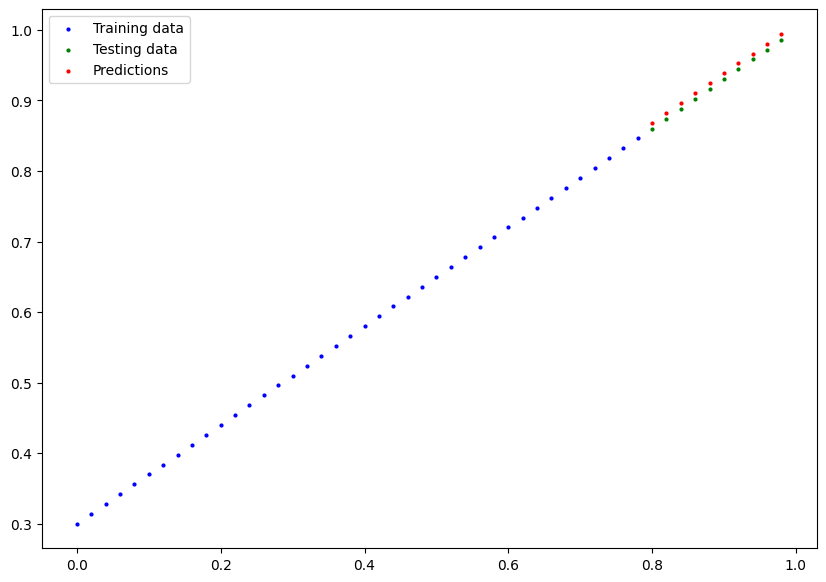

In [ ]:
plot_preds(X_train,y_train,X_test,y_test,test_pred)

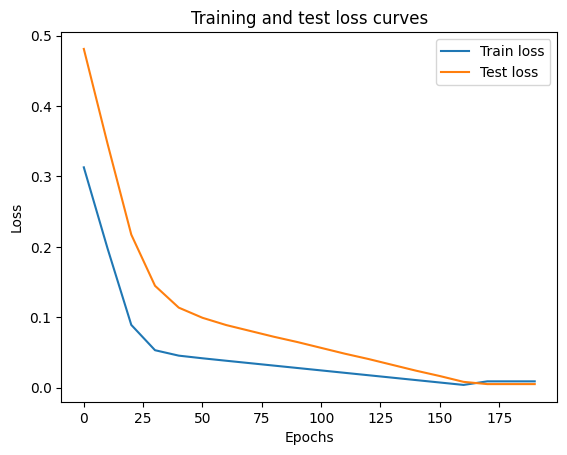

In [ ]:
plt.plot(epoch_count,loss_values,label="Train loss")
plt.plot(epoch_count,test_loss_values,label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [ ]:
from pathlib import Path

MODEL_FOLDER = Path("models")
MODEL_FOLDER.mkdir(parents=True,exist_ok=True)

MODEL_NAME = "lr.pt"

MODEL_PATH = MODEL_FOLDER / MODEL_NAME
MODEL_PATH

PosixPath('models/lr.pt')

In [ ]:
torch.save(model.state_dict(),MODEL_PATH)

In [ ]:
!ls -l ./models

total 4
-rw-r--r-- 1 root root 1661 Sep 28 03:52 lr.pt


In [ ]:
model = LinearRegressionModel()
model.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
model.load_state_dict(torch.load(MODEL_PATH))
model.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
class LinearRegressionModel(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.linear_layer = nn.Linear(in_features=1,out_features=1)

  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

In [ ]:
torch.manual_seed(42)
model = LinearRegressionModel()
optimizer = torch.optim.SGD(params=model.parameters(),lr=0.01)

In [ ]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)
model.to(device)

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
model.eval() # sets the model in evaluation mode

with torch.inference_mode():
  test_pred = model(X_test)
  test_loss = loss_fn(test_pred,y_test)

test_pred, test_loss

(tensor([[1.4416],
         [1.4569],
         [1.4722],
         [1.4875],
         [1.5028],
         [1.5181],
         [1.5334],
         [1.5487],
         [1.5640],
         [1.5793]]),
 tensor(0.5874))

In [ ]:
epochs = 200
torch.manual_seed(42)

epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
  model.train() # sets the model in training mode
  y_pred = model(X_train) # forward propagation
  loss = loss_fn(y_pred,y_train) # calculate loss
  optimizer.zero_grad() # optimizer zero grad
  loss.backward() # backward propagation
  optimizer.step() # step the optimizer

  model.eval() # sets the model in evaluation mode
  with torch.inference_mode():
    test_pred = model(X_test)
    test_loss = loss_fn(test_pred,y_test)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss.detach())
    test_loss_values.append(test_loss)

In [ ]:
model.eval() # sets the model in evaluation mode

with torch.inference_mode():
  test_pred = model(X_test)
  test_loss = loss_fn(test_pred,y_test)

test_pred, test_loss

(tensor([[0.8600],
         [0.8739],
         [0.8878],
         [0.9018],
         [0.9157],
         [0.9296],
         [0.9436],
         [0.9575],
         [0.9714],
         [0.9854]]),
 tensor(0.0003))

In [ ]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

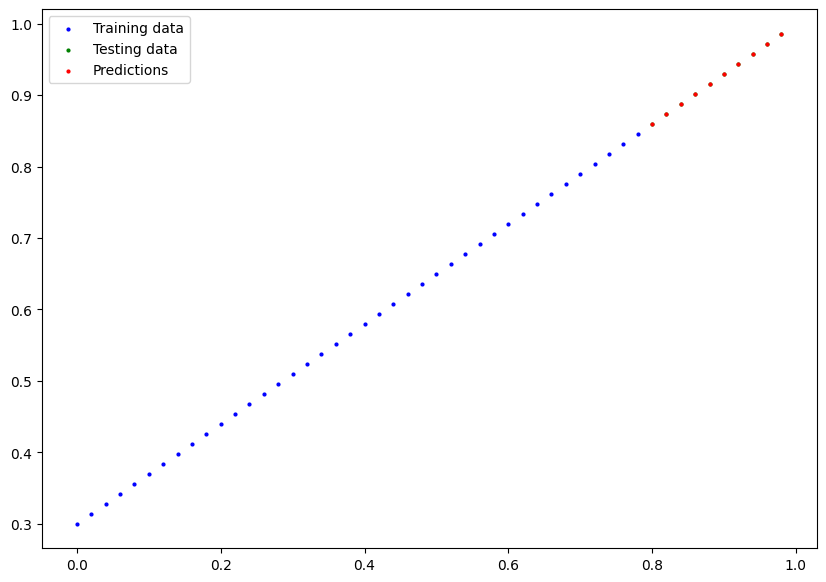

In [ ]:
plot_preds(X_train,y_train,X_test,y_test,test_pred)

In [ ]:
state_dict = torch.load(MODEL_PATH)
model.load_state_dict({"linear_layer.weight":state_dict["weight"].unsqueeze(dim=1),"linear_layer.bias":state_dict["bias"]})
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6990]])),
             ('linear_layer.bias', tensor([0.3093]))])